# ANOVA em codigo

Este notebook acompanha `GCC1625_05_anova.pdf` como companion pratico. A teoria, a motivacao e as formulas estao nas notas; aqui o foco e transformar cada etapa em codigo executavel.

Roteiro do notebook:
1. mostrar por que varios `t`-testes nao sao a estrategia correta;
2. visualizar a distribuicao `F` e calcular a ANOVA manualmente;
3. reproduzir os exemplos `PlantGrowth` e `SandwichAnts` das notas;
4. aplicar Tukey quando a ANOVA rejeitar `H_0`.

In [1]:
from io import StringIO
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import f as f_dist
from scipy.stats import f_oneway, levene, shapiro, ttest_ind
from statsmodels.stats.multicomp import pairwise_tukeyhsd

ALPHA = 0.05
RNG = np.random.default_rng(1625)
DATA_DIR = Path.cwd().parent / "data" if Path.cwd().name == "notebooks" else Path.cwd() / "data"

## 1. Por que nao comparar tudo com varios t-testes?

As notas motivam a ANOVA observando que comparar todos os pares separadamente infla a chance de pelo menos um falso positivo. A celula abaixo faz duas coisas:

- calcula quantos testes seriam necessarios para `k` grupos;
- simula um caso em que todas as medias sao iguais e mede a taxa de falso positivo quando usamos varios `t`-testes independentes.

In [2]:
def resumo_multiplos_testes(k_vals=(3, 4, 5), alpha=ALPHA):
    linhas = []
    for k in k_vals:
        m = k * (k - 1) // 2
        linhas.append({
            'k_grupos': k,
            'comparacoes_em_pares': m,
            'fwer_aprox': 1 - (1 - alpha) ** m,
        })
    return pd.DataFrame(linhas).round(4)


def simular_falso_positivo_t_tests(k=4, n=20, sigma=1.0, n_rep=5000, alpha=ALPHA, seed=1625):
    rng = np.random.default_rng(seed)
    rejeitou_algum = 0
    for _ in range(n_rep):
        grupos = [rng.normal(loc=0.0, scale=sigma, size=n) for _ in range(k)]
        p_vals = [ttest_ind(a, b, equal_var=True).pvalue for a, b in combinations(grupos, 2)]
        rejeitou_algum += any(p <= alpha for p in p_vals)
    return rejeitou_algum / n_rep

resumo_multiplos_testes()

,k_grupos,comparacoes_em_pares,fwer_aprox
0,3,3,0.1426
1,4,6,0.2649
2,5,10,0.4013


In [3]:
taxa_fp = simular_falso_positivo_t_tests(k=4, n=20)
print(f"Taxa simulada de pelo menos um falso positivo com 4 grupos: {taxa_fp:.4f}")

Taxa simulada de pelo menos um falso positivo com 4 grupos: 0.2004


## 2. Distribuicao F

A ANOVA usa a estatistica `F`, que compara a variabilidade entre grupos com a variabilidade dentro dos grupos. O grafico abaixo replica a ideia da Figura 1 das notas: a forma da distribuicao depende dos graus de liberdade do numerador e do denominador.

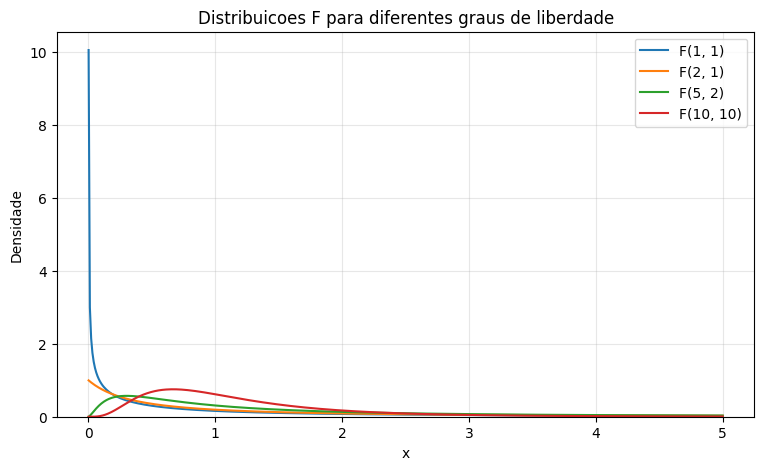

In [4]:
x = np.linspace(0.001, 5, 500)
parametros_f = [(1, 1), (2, 1), (5, 2), (10, 10)]

plt.figure(figsize=(9, 5))
for d1, d2 in parametros_f:
    plt.plot(x, f_dist.pdf(x, d1, d2), label=f'F({d1}, {d2})')

plt.title('Distribuicoes F para diferentes graus de liberdade')
plt.xlabel('x')
plt.ylabel('Densidade')
plt.ylim(bottom=0)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. Funcoes auxiliares

As funcoes abaixo encapsulam o roteiro operacional da aula: separar grupos, resumir os dados, verificar as condicoes de aplicabilidade, decompor a variabilidade e aplicar ANOVA e Tukey.

In [5]:
def separar_grupos(df, grupo_col, valor_col):
    return {
        grupo: dados[valor_col].dropna().to_numpy()
        for grupo, dados in df.groupby(grupo_col, sort=True)
    }


def resumo_por_grupo(df, grupo_col, valor_col):
    return (
        df.groupby(grupo_col)[valor_col]
        .agg(n='count', media='mean', desvio_padrao='std', variancia='var')
        .round(4)
    )


def verificar_condicoes(grupos, alpha=ALPHA):
    lev_stat, lev_p = levene(*grupos.values(), center='mean')
    linhas = [{
        'verificacao': 'Levene (variancias iguais)',
        'grupo': 'todos',
        'estatistica': lev_stat,
        'p_valor': lev_p,
        'nao_rejeita_H0': lev_p > alpha,
    }]
    for nome, valores in grupos.items():
        shap_stat, shap_p = shapiro(valores)
        linhas.append({
            'verificacao': 'Shapiro-Wilk (normalidade)',
            'grupo': nome,
            'estatistica': shap_stat,
            'p_valor': shap_p,
            'nao_rejeita_H0': shap_p > alpha,
        })
    return pd.DataFrame(linhas).round(4)


def tabela_anova_manual(grupos):
    valores = np.concatenate(list(grupos.values()))
    media_global = valores.mean()
    k = len(grupos)
    n_total = len(valores)

    ss_entre = sum(len(x) * (x.mean() - media_global) ** 2 for x in grupos.values())
    ss_dentro = sum(((x - x.mean()) ** 2).sum() for x in grupos.values())
    ss_total = ((valores - media_global) ** 2).sum()

    gl_entre = k - 1
    gl_dentro = n_total - k
    gl_total = n_total - 1

    ms_entre = ss_entre / gl_entre
    ms_dentro = ss_dentro / gl_dentro
    f_manual = ms_entre / ms_dentro
    p_valor = f_dist.sf(f_manual, gl_entre, gl_dentro)

    tabela = pd.DataFrame({
        'fonte': ['entre grupos', 'dentro dos grupos', 'total'],
        'SQ': [ss_entre, ss_dentro, ss_total],
        'gl': [gl_entre, gl_dentro, gl_total],
        'QM': [ms_entre, ms_dentro, np.nan],
        'F': [f_manual, np.nan, np.nan],
    }).round(4)

    resumo = pd.Series({
        'media_global': round(media_global, 4),
        'F_manual': round(f_manual, 4),
        'p_valor_F': round(p_valor, 4),
    })
    return tabela, resumo


def aplicar_anova(grupos, alpha=ALPHA):
    f_stat, p_value = f_oneway(*grupos.values())
    return pd.Series({
        'F_scipy': round(f_stat, 4),
        'p_valor': round(p_value, 4),
        'rejeita_H0': p_value <= alpha,
    })


def aplicar_tukey(df, grupo_col, valor_col, alpha=ALPHA):
    tukey = pairwise_tukeyhsd(endog=df[valor_col], groups=df[grupo_col], alpha=alpha)
    tabela = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
    for col in ['meandiff', 'p-adj', 'lower', 'upper']:
        tabela[col] = pd.to_numeric(tabela[col])
    return tukey, tabela


def plotar_tukey(tukey_df, titulo):
    dados = tukey_df.copy()
    dados['comparacao'] = dados['group1'].astype(str) + ' vs ' + dados['group2'].astype(str)
    dados = dados.sort_values('meandiff').reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8, 4))
    y = np.arange(len(dados))
    cores = np.where(dados['reject'], 'tab:red', 'tab:gray')
    for yi, row, cor in zip(y, dados.itertuples(index=False), cores):
        ax.hlines(y=yi, xmin=row.lower, xmax=row.upper, color=cor, linewidth=2)
        ax.plot(row.meandiff, yi, 'o', color=cor)
    ax.axvline(0, color='tab:blue', linestyle='--', label='diferenca = 0')
    ax.set_yticks(y)
    ax.set_yticklabels(dados['comparacao'])
    ax.set_xlabel('Diferenca de medias')
    ax.set_title(titulo)
    ax.grid(True, axis='x', alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return ax

## 4. Exemplo 1 das notas: PlantGrowth

A pergunta de pesquisa e: ha diferenca entre os pesos medios dos frutos nos grupos `ctrl`, `trt1` e `trt2`?

- Variavel independente: `group`
- Variavel dependente: `weight`
- `H_0`: todas as medias populacionais sao iguais
- `H_a`: pelo menos um par de medias difere

In [6]:
plantgrowth_csv = 'rownames,weight,group\n1,4.17,ctrl\n2,5.58,ctrl\n3,5.18,ctrl\n4,6.11,ctrl\n5,4.50,ctrl\n6,4.61,ctrl\n7,5.17,ctrl\n8,4.53,ctrl\n9,5.33,ctrl\n10,5.14,ctrl\n11,4.81,trt1\n12,4.17,trt1\n13,4.41,trt1\n14,3.59,trt1\n15,5.87,trt1\n16,3.83,trt1\n17,6.03,trt1\n18,4.89,trt1\n19,4.32,trt1\n20,4.69,trt1\n21,6.31,trt2\n22,5.12,trt2\n23,5.54,trt2\n24,5.50,trt2\n25,5.37,trt2\n26,5.29,trt2\n27,4.92,trt2\n28,6.15,trt2\n29,5.80,trt2\n30,5.26,trt2\n'

try:
    frutos_df = pd.read_csv(DATA_DIR / 'PlantGrowth.csv')
except FileNotFoundError:
    frutos_df = pd.read_csv(StringIO(plantgrowth_csv))

frutos_df.head()

,rownames,weight,group
0,1,4.17,ctrl
1,2,5.58,ctrl
2,3,5.18,ctrl
3,4,6.11,ctrl
4,5,4.50,ctrl


In [7]:
grupos_frutos = separar_grupos(frutos_df, 'group', 'weight')
resumo_por_grupo(frutos_df, 'group', 'weight')

,n,media,desvio_padrao,variancia
group,,,,
ctrl,10,5.032,0.5831,0.3400
trt1,10,4.661,0.7937,0.6299
trt2,10,5.526,0.4426,0.1959


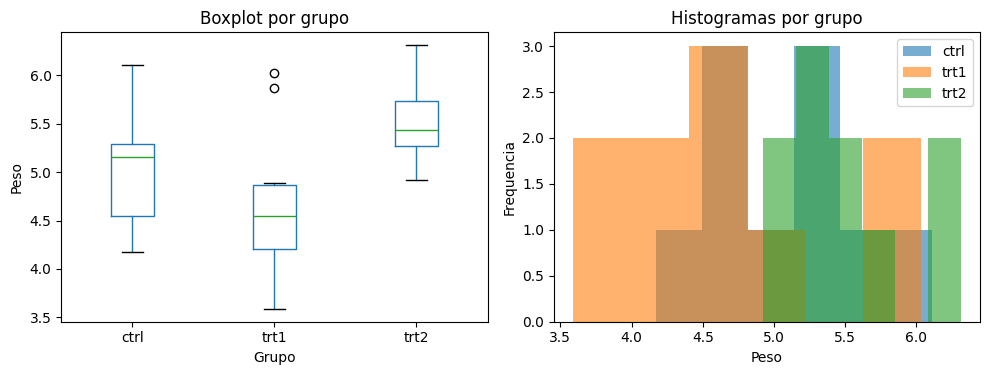

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
frutos_df.boxplot(column='weight', by='group', grid=False, ax=axes[0])
axes[0].set_title('Boxplot por grupo')
axes[0].set_xlabel('Grupo')
axes[0].set_ylabel('Peso')

for grupo, valores in grupos_frutos.items():
    axes[1].hist(valores, alpha=0.6, bins=6, label=grupo)
axes[1].set_title('Histogramas por grupo')
axes[1].set_xlabel('Peso')
axes[1].set_ylabel('Frequencia')
axes[1].legend()
plt.suptitle('')
plt.tight_layout()
plt.show()

### Verificacao das condicoes

As notas usam Levene para homocedasticidade e normalidade por grupo. Aqui usamos Shapiro-Wilk para normalidade porque os grupos sao pequenos (`n = 10`). O resultado deve ser lido como evidencia auxiliar, nao como garantia automatica de validade.

In [9]:
verificar_condicoes(grupos_frutos)

,verificacao,grupo,estatistica,p_valor,nao_rejeita_H0
0,Levene (variancias iguais),todos,1.2370,0.3062,True
1,Shapiro-Wilk (normalidade),ctrl,0.9567,0.7475,True
2,Shapiro-Wilk (normalidade),trt1,0.9304,0.4519,True
3,Shapiro-Wilk (normalidade),trt2,0.9410,0.5643,True


### Particao da variabilidade: da formula ao codigo

A proxima celula implementa exatamente o que as notas descrevem: soma de quadrados entre grupos, soma de quadrados dentro dos grupos, quadrados medios, estatistica `F` e p-valor associado a `F(d_1, d_2)`.

In [10]:
anova_manual_frutos, resumo_manual_frutos = tabela_anova_manual(grupos_frutos)
print(resumo_manual_frutos)
anova_manual_frutos

media_global    5.0730
F_manual        4.8461
p_valor_F       0.0159
dtype: float64


,fonte,SQ,gl,QM,F
0,entre grupos,3.7663,2,1.8832,4.8461
1,dentro dos grupos,10.4921,27,0.3886,NaN
2,total,14.2584,29,NaN,NaN


In [11]:
resultado_frutos = aplicar_anova(grupos_frutos)
resultado_frutos

F_scipy       4.8461
p_valor       0.0159
rejeita_H0      True
dtype: object

A comparacao relevante aqui e entre `F_manual` e `F_scipy`: eles devem coincidir a menos de arredondamento. Se `p_valor < 0.05`, rejeitamos `H_0` e concluimos apenas que existe diferenca entre pelo menos dois grupos. A ANOVA nao identifica quais grupos diferem.

## 5. Exemplo 2 das notas: SandwichAnts

Agora aplicamos ANOVA ao experimento dos sanduiches.

- Variavel independente: `Filling`
- Variavel dependente: `Ants`
- `H_0`: os tres recheios tem a mesma media populacional de formigas atraidas
- `H_a`: pelo menos um par de medias difere

In [12]:
sanduiches_df = pd.read_csv(DATA_DIR / 'SandwichAnts.csv')
grupos_formigas = separar_grupos(sanduiches_df, 'Filling', 'Ants')

resumo_por_grupo(sanduiches_df, 'Filling', 'Ants')

,n,media,desvio_padrao,variancia
Filling,,,,
HamPickles,16,55.500,12.0554,145.3333
PeanutButter,16,40.375,14.1839,201.1833
Vegemite,16,34.625,11.1587,124.5167


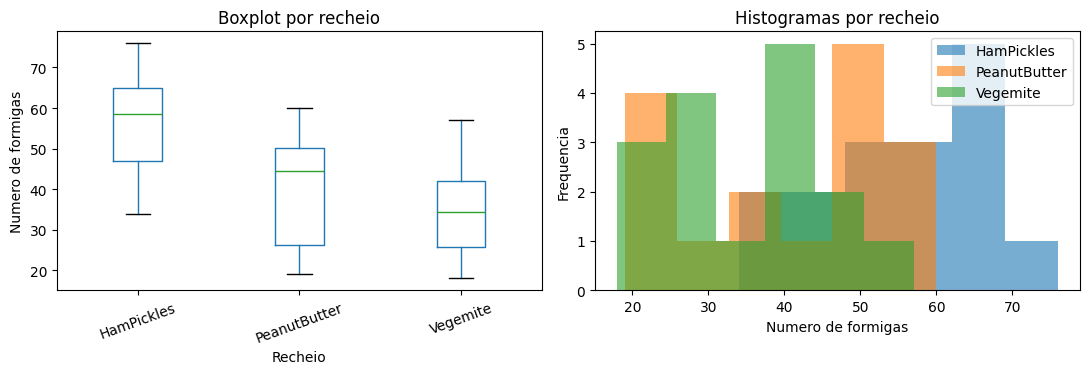

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sanduiches_df.boxplot(column='Ants', by='Filling', grid=False, rot=20, ax=axes[0])
axes[0].set_title('Boxplot por recheio')
axes[0].set_xlabel('Recheio')
axes[0].set_ylabel('Numero de formigas')

for grupo, valores in grupos_formigas.items():
    axes[1].hist(valores, alpha=0.6, bins=6, label=grupo)
axes[1].set_title('Histogramas por recheio')
axes[1].set_xlabel('Numero de formigas')
axes[1].set_ylabel('Frequencia')
axes[1].legend()
plt.suptitle('')
plt.tight_layout()
plt.show()

In [14]:
print('Condicoes de aplicabilidade')
verificar_condicoes(grupos_formigas)

Condicoes de aplicabilidade


,verificacao,grupo,estatistica,p_valor,nao_rejeita_H0
0,Levene (variancias iguais),todos,0.8962,0.4153,True
1,Shapiro-Wilk (normalidade),HamPickles,0.9535,0.5463,True
2,Shapiro-Wilk (normalidade),PeanutButter,0.9159,0.1451,True
3,Shapiro-Wilk (normalidade),Vegemite,0.9539,0.5545,True


In [15]:
anova_manual_formigas, resumo_manual_formigas = tabela_anova_manual(grupos_formigas)
print(resumo_manual_formigas)
anova_manual_formigas

media_global    43.5000
F_manual        11.8479
p_valor_F        0.0001
dtype: float64


,fonte,SQ,gl,QM,F
0,entre grupos,3720.5,2,1860.2500,11.8479
1,dentro dos grupos,7065.5,45,157.0111,NaN
2,total,10786.0,47,NaN,NaN


In [16]:
resultado_formigas = aplicar_anova(grupos_formigas)
resultado_formigas

F_scipy       11.8479
p_valor        0.0001
rejeita_H0       True
dtype: object

## 6. Tukey post-hoc

Se a ANOVA rejeitar `H_0`, o proximo passo e identificar quais pares diferem. O teste de Tukey responde exatamente essa pergunta, controlando o erro tipo I nas comparacoes multiplas.

In [17]:
tukey_formigas, tukey_formigas_df = aplicar_tukey(sanduiches_df, 'Filling', 'Ants')
tukey_formigas_df

,group1,group2,meandiff,p-adj,lower,upper,reject
0,HamPickles,PeanutButter,-15.125,0.0038,-25.862,-4.388,True
1,HamPickles,Vegemite,-20.875,0.0001,-31.612,-10.138,True
2,PeanutButter,Vegemite,-5.750,0.4037,-16.487,4.987,False


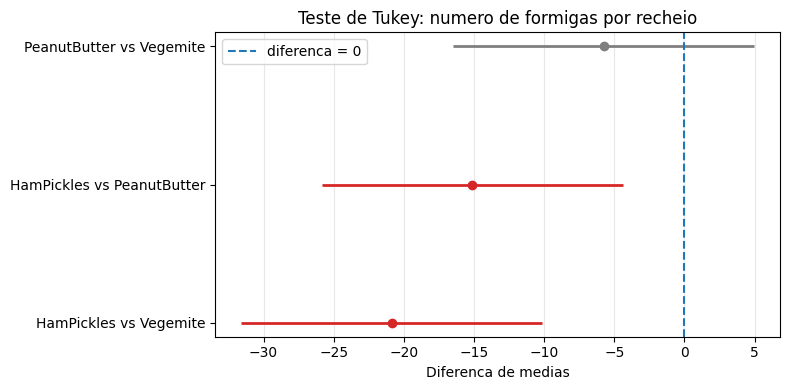

In [18]:
plotar_tukey(tukey_formigas_df, 'Teste de Tukey: numero de formigas por recheio')
plt.show()

A coluna `reject` e a maneira mais direta de ler a saida: `True` significa diferenca estatisticamente significativa para aquele par. O grafico reforca a mesma ideia: intervalos que nao cruzam zero correspondem aos pares com diferenca significativa.

## 7. Roteiro reutilizavel

A funcao abaixo resume o workflow computacional da ANOVA de uma via. Ela serve para os exercicios das notas ou para novos conjuntos de dados no mesmo formato.

In [19]:
def roteiro_anova(df, grupo_col='Metodo', valor_col='Nota', alpha=ALPHA):
    grupos = separar_grupos(df, grupo_col, valor_col)

    print('Resumo por grupo')
    print(resumo_por_grupo(df, grupo_col, valor_col))

    print('\nCondicoes de aplicabilidade')
    print(verificar_condicoes(grupos, alpha=alpha))

    print('\nANOVA manual')
    tabela_manual, resumo_manual = tabela_anova_manual(grupos)
    print(resumo_manual)
    print(tabela_manual)

    print('\nANOVA com scipy')
    resultado = aplicar_anova(grupos, alpha=alpha)
    print(resultado)

    if bool(resultado['rejeita_H0']):
        print('\nTukey')
        _, tukey_df = aplicar_tukey(df, grupo_col, valor_col, alpha=alpha)
        print(tukey_df)
        plotar_tukey(tukey_df, f'Tukey: {valor_col} por {grupo_col}')
        plt.show()
    else:
        print('\nComo a ANOVA nao rejeitou H0, Tukey nao e necessario.')


## 8. Exercicios guiados

Os arquivos abaixo correspondem a exercicios alinhados com o tema das notas. O companion notebook deixa o roteiro pronto; basta carregar um dos CSVs e chamar `roteiro_anova`.

In [20]:
arquivos_exercicios = {
    'metodo_estudo': DATA_DIR / 'anova' / 'MetodoEstudo.csv',
    'fertilizante': DATA_DIR / 'anova' / 'Fertilizante.csv',
    'satisfacao_celular': DATA_DIR / 'anova' / 'SatisfacaoCelular.csv',
}

for nome, arquivo in arquivos_exercicios.items():
    print(f'{nome}: {arquivo}')

metodo_estudo: /Users/ebezerra/ailab/gcc1625/data/anova/MetodoEstudo.csv
fertilizante: /Users/ebezerra/ailab/gcc1625/data/anova/Fertilizante.csv
satisfacao_celular: /Users/ebezerra/ailab/gcc1625/data/anova/SatisfacaoCelular.csv


Resumo por grupo
             n   media  desvio_padrao  variancia
Metodo                                          
Grupo       30  7.3273         1.1094     1.2307
Individual  30  6.5447         1.1872     1.4094
Revisao     30  7.9369         0.8499     0.7224

Condicoes de aplicabilidade
                  verificacao       grupo  estatistica  p_valor  \
0  Levene (variancias iguais)       todos       2.1421   0.1236   
1  Shapiro-Wilk (normalidade)       Grupo       0.9875   0.9717   
2  Shapiro-Wilk (normalidade)  Individual       0.9621   0.3509   
3  Shapiro-Wilk (normalidade)     Revisao       0.9775   0.7572   

   nao_rejeita_H0  
0            True  
1            True  
2            True  
3            True  

ANOVA manual
media_global     7.2697
F_manual        13.0362
p_valor_F        0.0000
dtype: float64
               fonte        SQ  gl       QM        F
0       entre grupos   29.2237   2  14.6118  13.0362
1  dentro dos grupos   97.5151  87   1.1209      NaN
2            

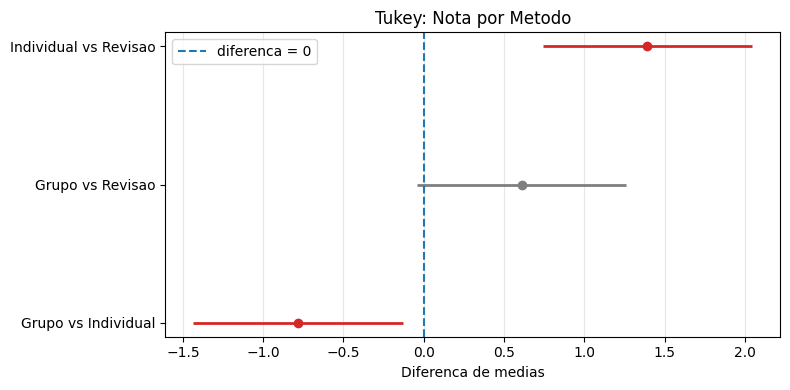

In [21]:
metodo_df = pd.read_csv(arquivos_exercicios['metodo_estudo'])
roteiro_anova(metodo_df)

## Fechamento

Use este notebook como checklist computacional da ANOVA de uma via:

1. identificar a variavel de grupo e a variavel numerica;
2. resumir os grupos e inspecionar a dispersao;
3. verificar homocedasticidade e normalidade;
4. calcular a ANOVA manualmente para entender a estatistica `F`;
5. aplicar `f_oneway` para obter `F` e p-valor;
6. usar Tukey apenas quando a ANOVA rejeitar `H_0`.